In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
data_path = "../data/raw/sp500_top10_stocks_raw.csv"

df = pd.read_csv(data_path)
df.head()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2010-01-04,AAPL,6.395005,6.427065,6.363544,6.412384,6.412384,493729600.0
1,2010-01-04,AMZN,6.812500,6.830500,6.657000,6.695000,6.695000,151998000.0
2,2010-01-04,AVGO,1.289115,1.331381,1.268686,1.328563,1.328563,5387000.0
3,2010-01-04,GOOG,15.498976,15.562262,15.431981,15.494032,15.494032,78541293.0
4,2010-01-04,GOOGL,15.571782,15.635366,15.504474,15.566814,15.566814,78169752.0


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
tickers = df['Ticker'].unique()

In [6]:
# create EDA report for stock price data of each ticker

for ticker in tickers:
    print(f"Processing EDA for: {ticker}")
    
    ticker_df = df[df['Ticker'] == ticker].copy()
    
    profile = ProfileReport(
        ticker_df, 
        tsmode=True, 
        sortby="Date", # sort chronologically
        title=f"Stock Price EDA Report - {ticker}",
        explorative=True,
        progress_bar=False,
    )
    
    profile.to_file(f"../reports/eda_reports/EDA_report_{ticker}.html")
    print(f"Finished EDA report for {ticker}")

Processing EDA for: AAPL


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.52it/s]


Finished EDA report for AAPL
Processing EDA for: AMZN


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.81it/s]


Finished EDA report for AMZN
Processing EDA for: AVGO


...

Finished EDA report for NVDA
Processing EDA for: TSLA


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.53it/s]


Finished EDA report for TSLA
Processing EDA for: META


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:03<00:00,  2.04it/s]


Finished EDA report for META


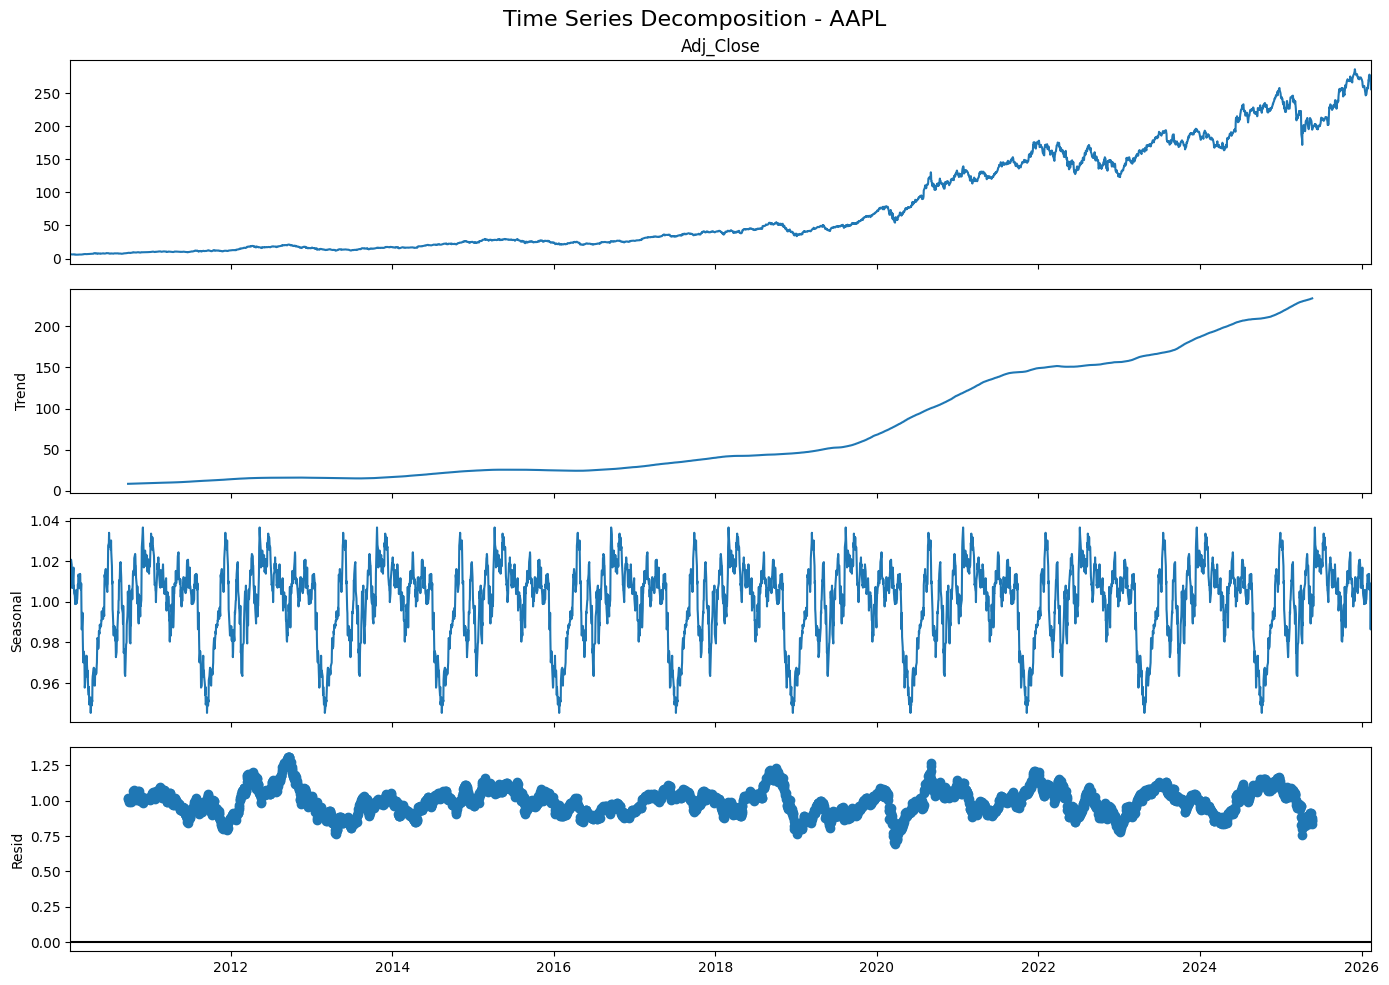

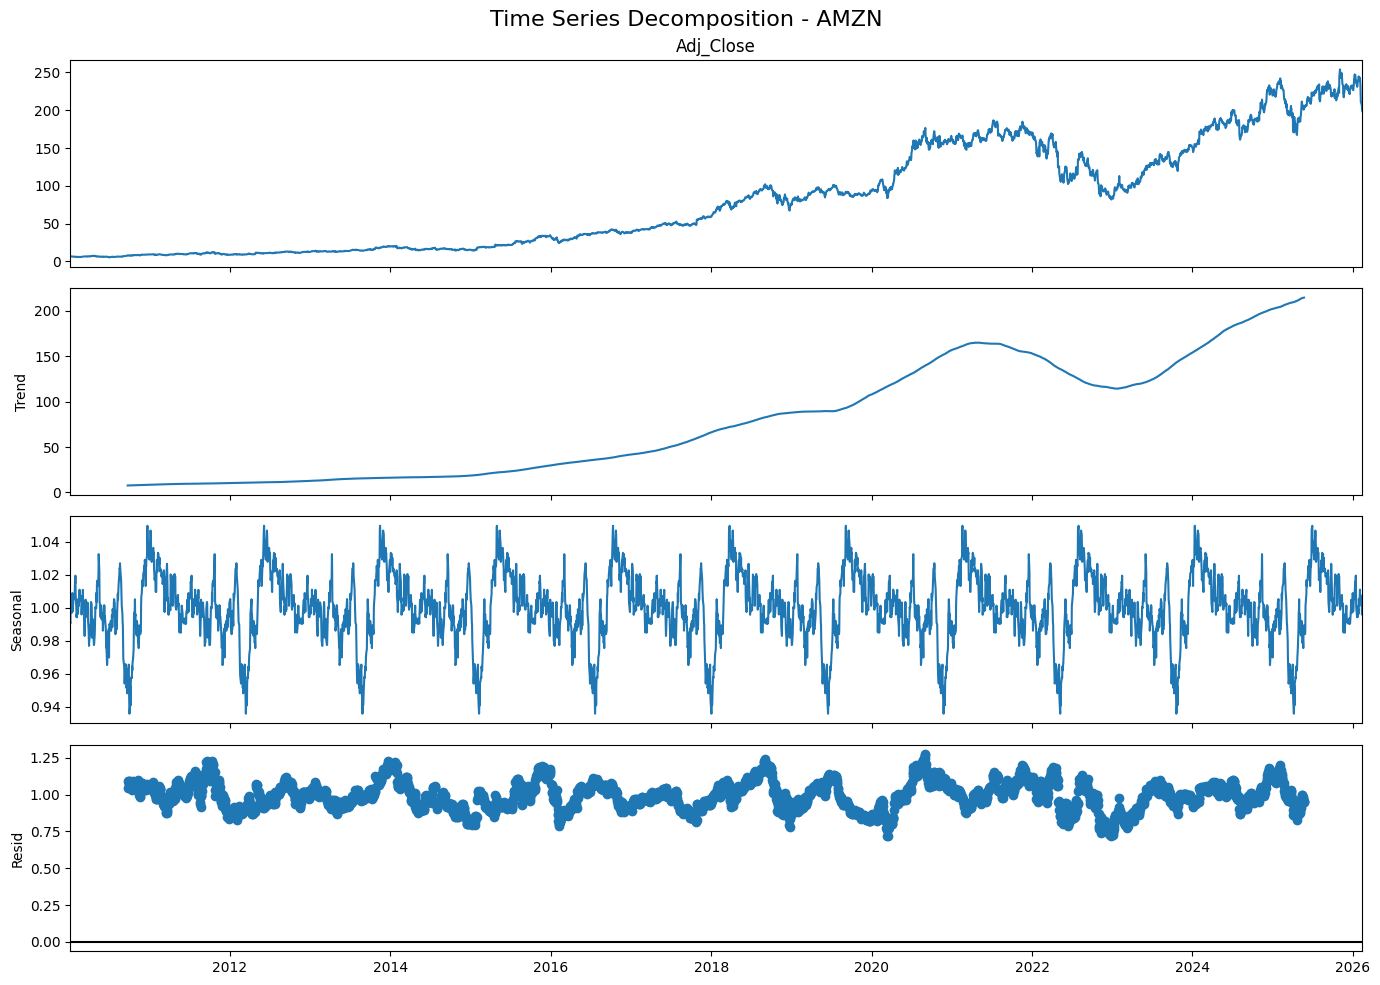

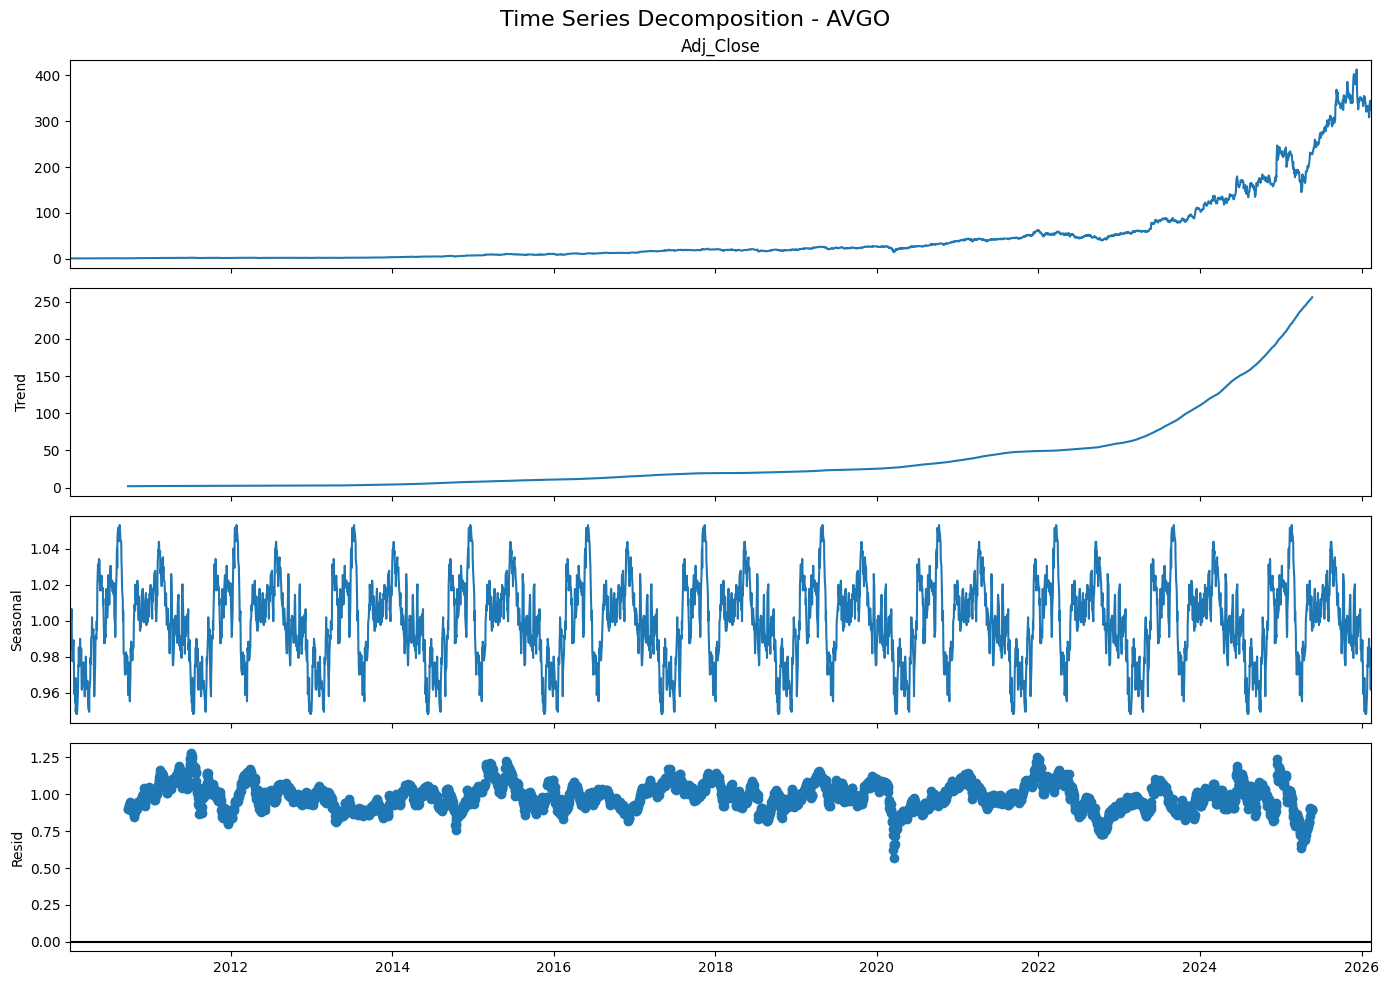

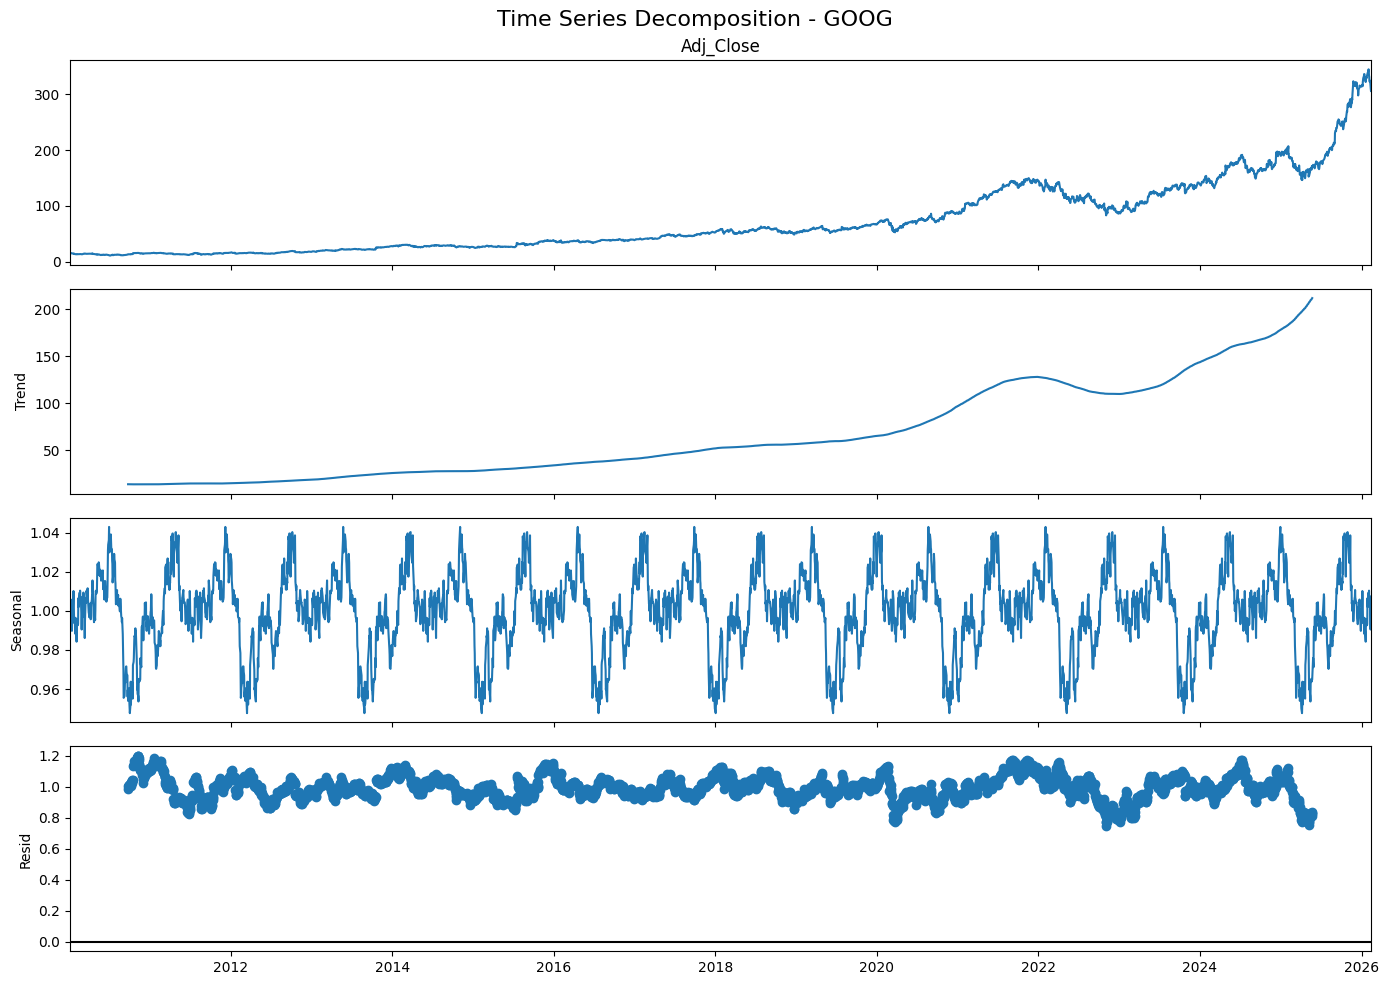

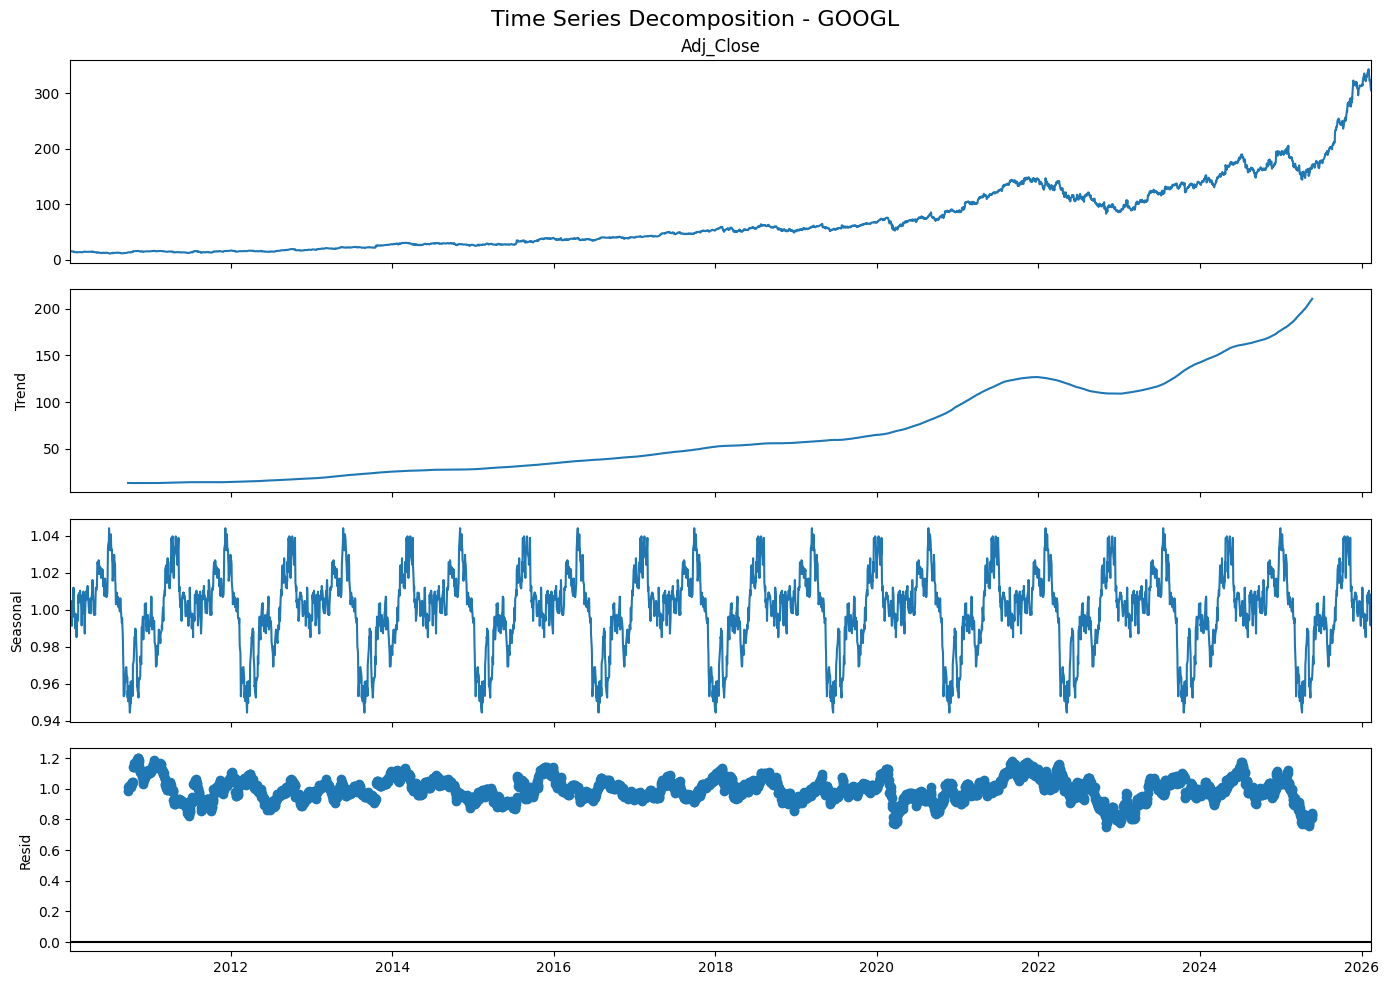

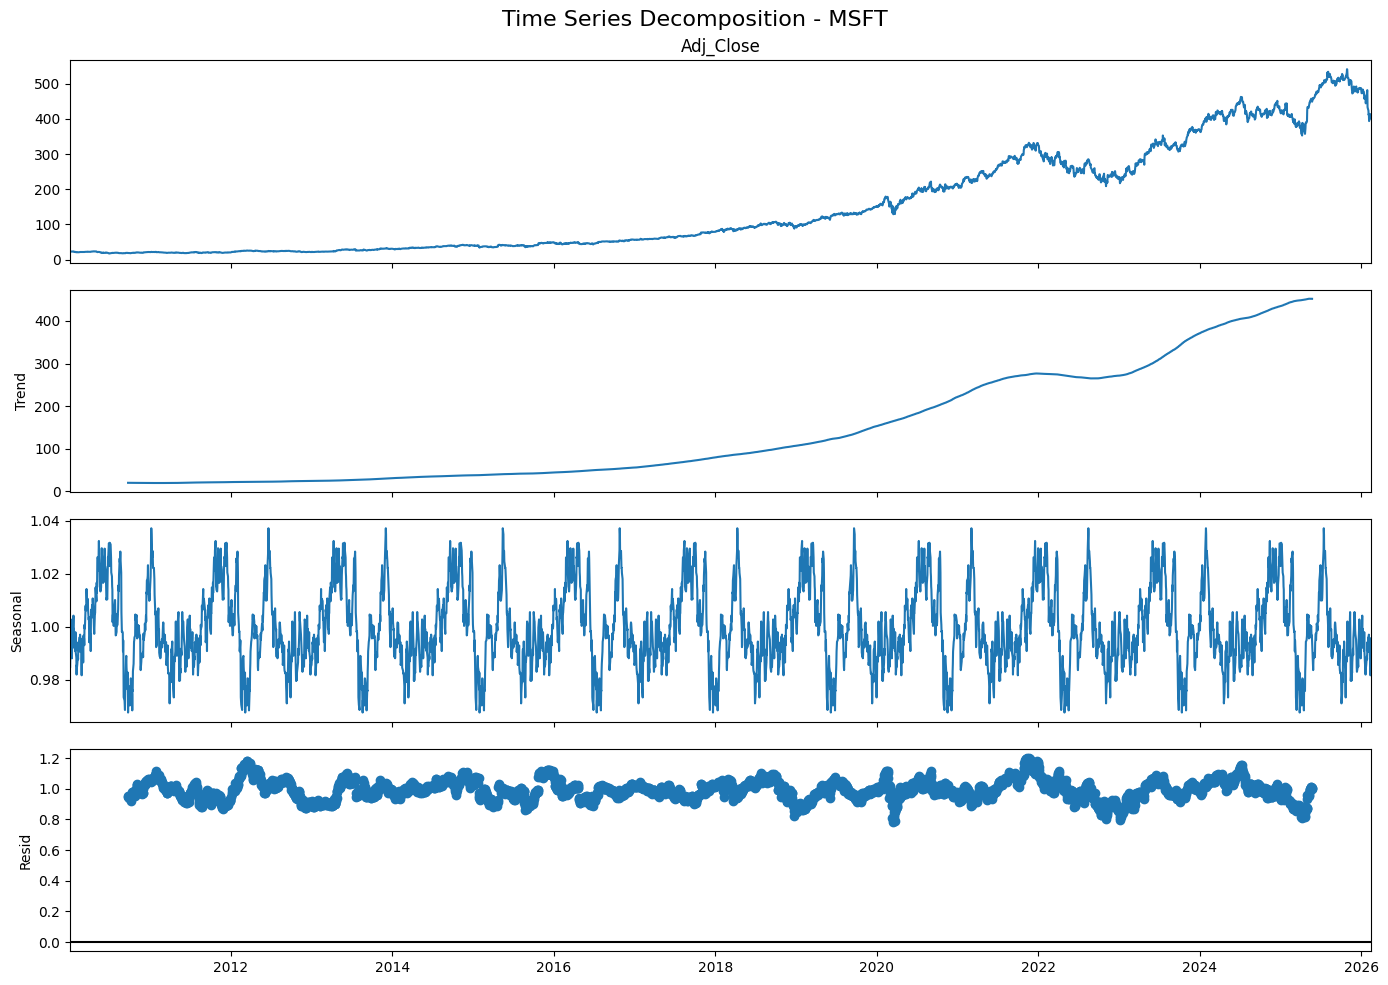

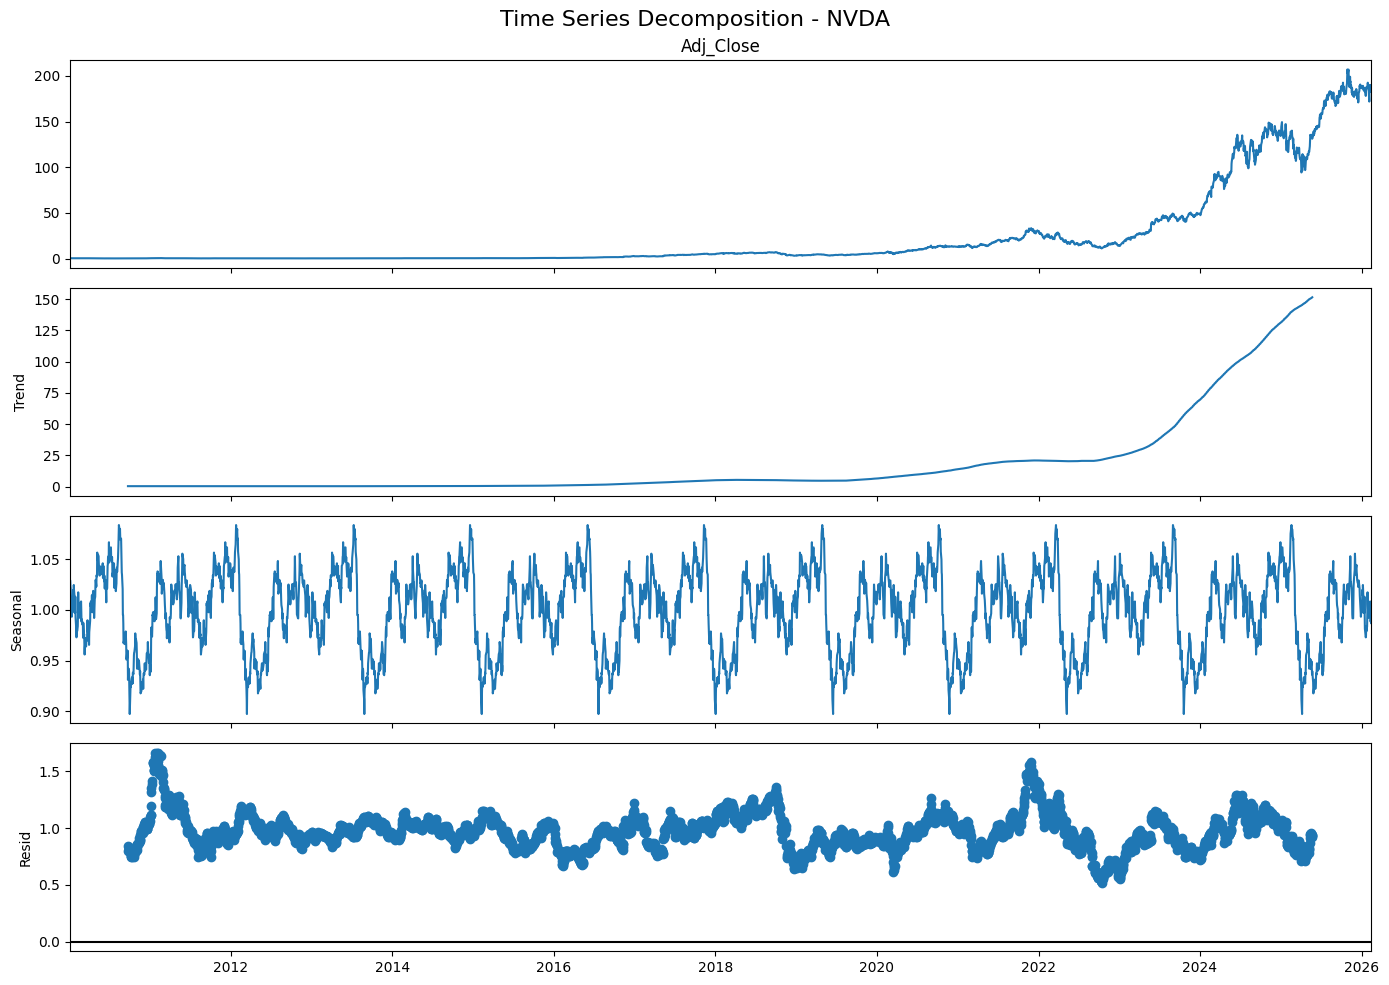

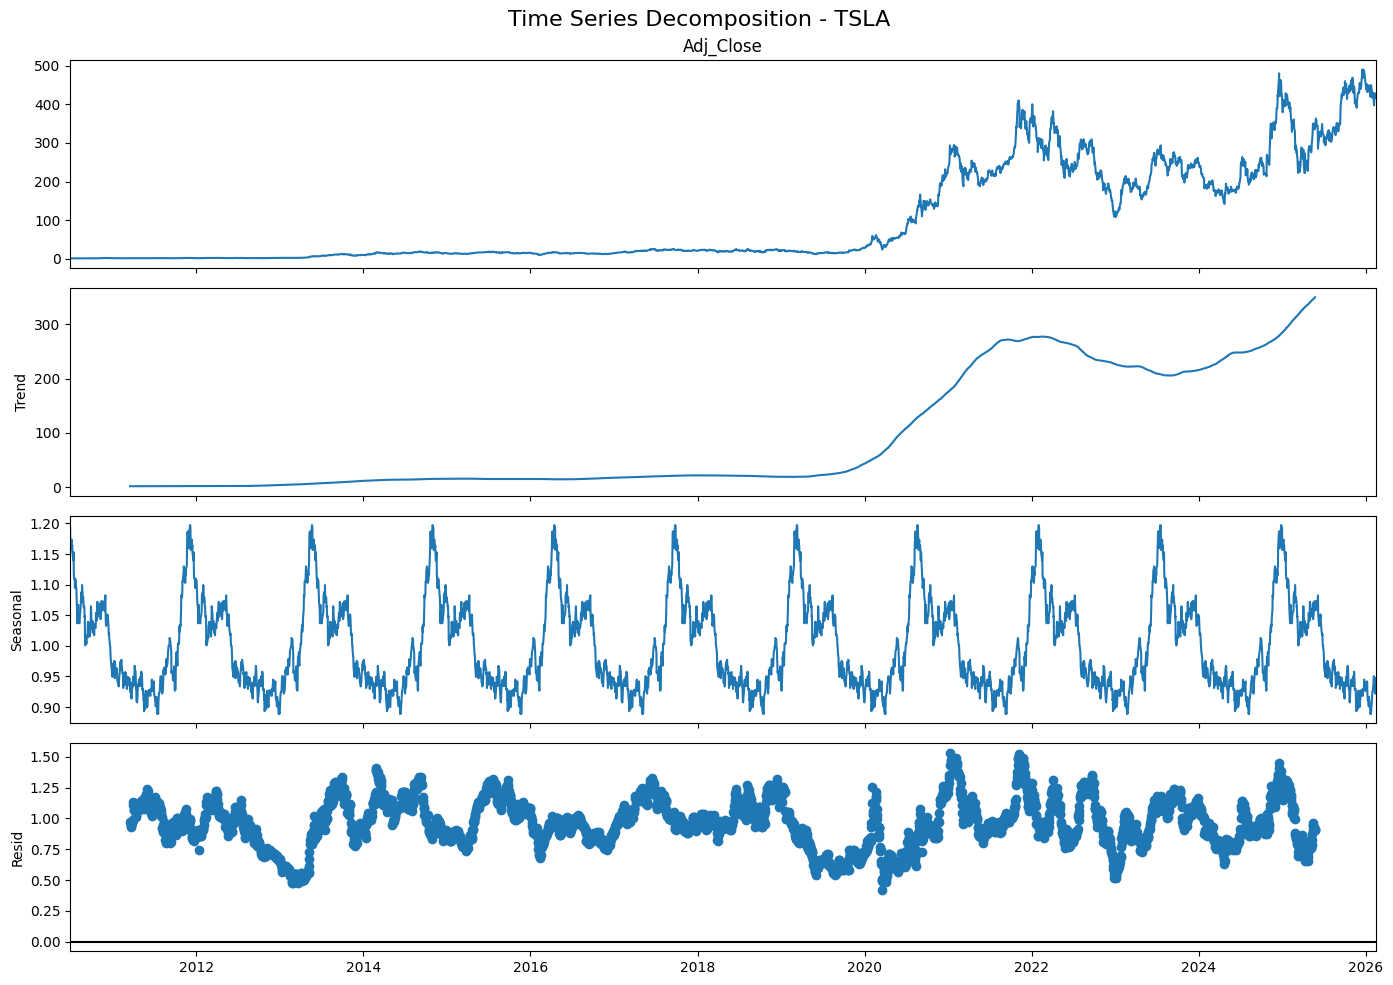

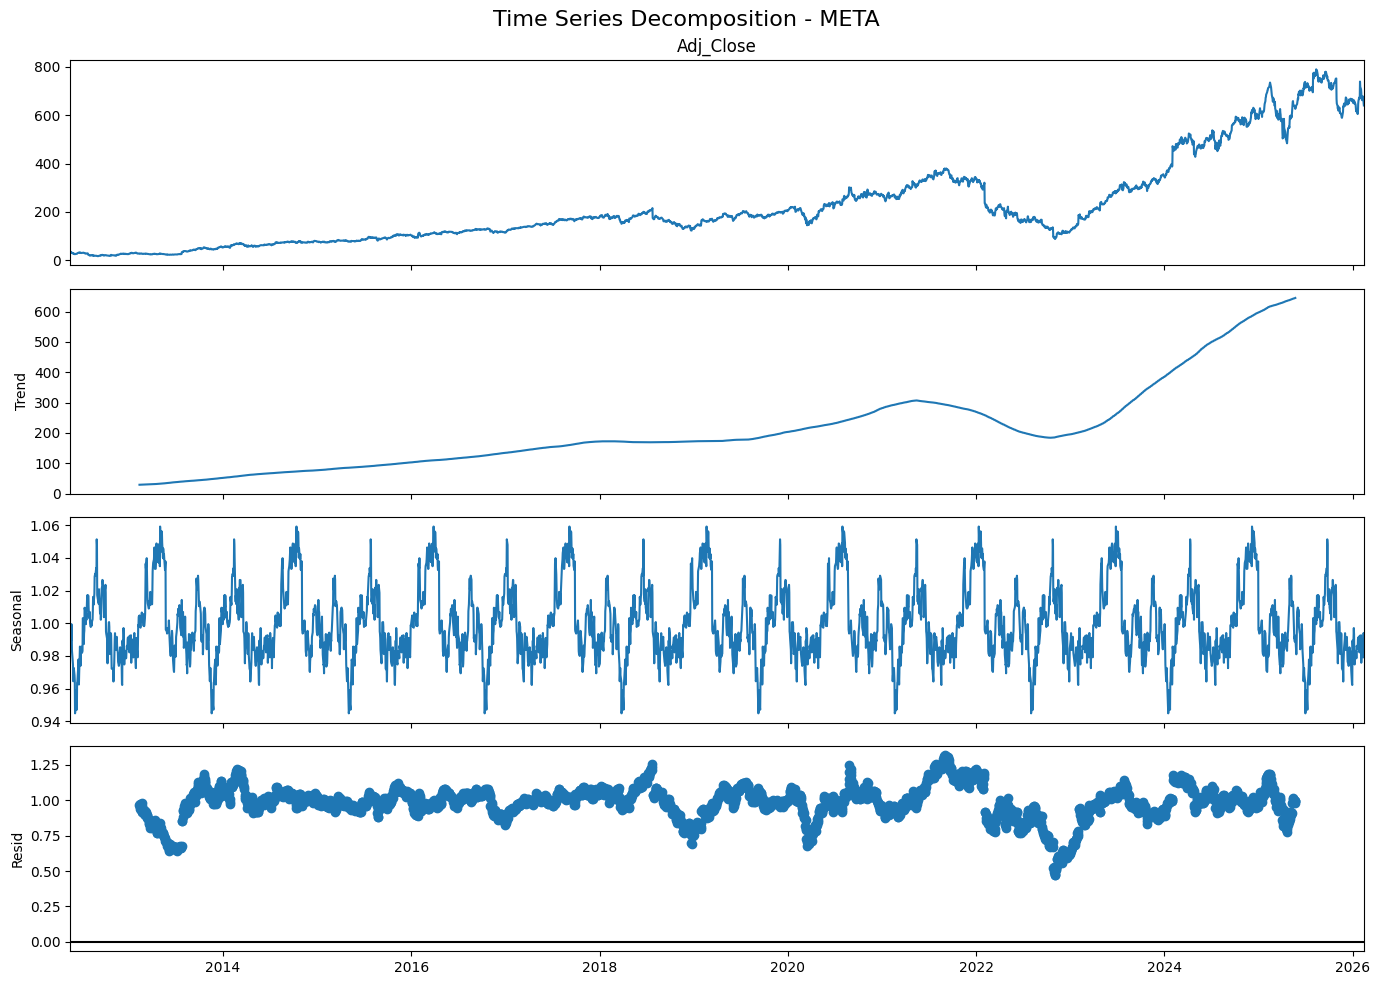

In [ ]:
# decompose time series components for each ticker stock price
for ticker in tickers:
    df_ticker = df[df['Ticker'] == ticker].sort_values('Date').copy()
    df_ticker.set_index('Date', inplace=True)
    ts = df_ticker['Adj_Close']
    decomposition = seasonal_decompose(ts, model='multiplicative', period=365)
    fig = decomposition.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle(f'Time Series Decomposition - {ticker}', fontsize=16)
    fig.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()